Consultando datos de USA...
Cargando datos de Colombia...

Cantidad de registros por país:
origen
USA         100
Colombia      7
Name: count, dtype: int64

Primeros registros:
                                              titulo       fecha  tipo origen
0  Search results for Group:words-And-Deeds, Avai...        None  None    USA
1               U.S. History Primary Source Timeline        None  None    USA
2                                                           None  None    USA
3                                   Today in History        None  None    USA
4  The Mississippi enterprise (Jackson, Miss.), F...  1944-02-26  None    USA

Promedio de año por país:
origen
Colombia    1988.571429
USA         2002.635135
Name: fecha, dtype: float64


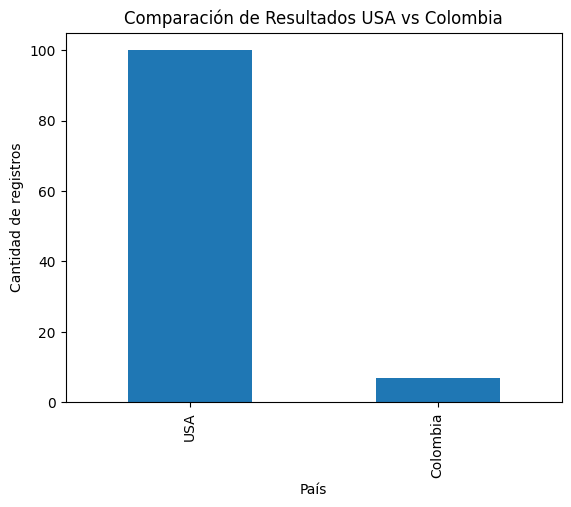

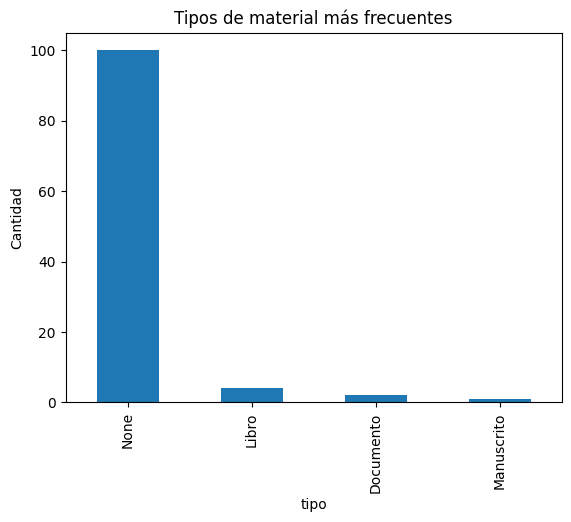


Proceso terminado correctamente.


In [2]:
# ==========================================
# COMPARACIÓN DE BIBLIOTECAS INTERNACIONALES
# USA vs COLOMBIA
# ==========================================

# Instalar librerías (solo necesario en Colab)
!pip install requests pandas matplotlib

import requests
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# FUNCIÓN 1: CONSULTAR LIBRARY OF CONGRESS
# ------------------------------------------

def buscar_loc(query, cantidad=100):
    url = "https://www.loc.gov/search/"
    params = {
        "q": query,
        "fo": "json",
        "c": cantidad
    }

    response = requests.get(url, params=params)
    data = response.json()

    resultados = []

    for item in data.get("results", []):
        resultados.append({
            "titulo": item.get("title"),
            "fecha": item.get("date"),
            "tipo": str(item.get("format")),
            "origen": "USA"
        })

    return pd.DataFrame(resultados)


# ------------------------------------------
# FUNCIÓN 2: DATOS SIMULADOS COLOMBIA
# ------------------------------------------

def buscar_bnc(query):

    datos = [
        {"titulo": "Historia de Colombia", "fecha": "1998", "tipo": "Libro"},
        {"titulo": "Independencia Colombiana", "fecha": "2005", "tipo": "Libro"},
        {"titulo": "Archivo histórico nacional", "fecha": "1980", "tipo": "Documento"},
        {"titulo": "Crónicas coloniales", "fecha": "1975", "tipo": "Manuscrito"},
        {"titulo": "Bibliografía colombiana", "fecha": "2010", "tipo": "Libro"},
        {"titulo": "Historia republicana", "fecha": "1992", "tipo": "Libro"},
        {"titulo": "Memorias del siglo XIX", "fecha": "1960", "tipo": "Documento"},
    ]

    df = pd.DataFrame(datos)
    df["origen"] = "Colombia"

    return df


# ------------------------------------------
# EJECUCIÓN PRINCIPAL
# ------------------------------------------

query = "history"

print("Consultando datos de USA...")
df_usa = buscar_loc(query, 100)

print("Cargando datos de Colombia...")
df_col = buscar_bnc(query)

# Unir datasets
df_total = pd.concat([df_usa, df_col], ignore_index=True)

# ------------------------------------------
# ANÁLISIS
# ------------------------------------------

print("\nCantidad de registros por país:")
print(df_total["origen"].value_counts())

print("\nPrimeros registros:")
print(df_total.head())

# ------------------------------------------
# LIMPIEZA DE FECHAS
# ------------------------------------------

df_total["fecha"] = pd.to_numeric(df_total["fecha"], errors="coerce")

# Promedio de año por país
print("\nPromedio de año por país:")
print(df_total.groupby("origen")["fecha"].mean())

# ------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------

conteo = df_total["origen"].value_counts()

plt.figure()
conteo.plot(kind="bar")
plt.title("Comparación de Resultados USA vs Colombia")
plt.ylabel("Cantidad de registros")
plt.xlabel("País")
plt.show()

# ------------------------------------------
# DISTRIBUCIÓN POR TIPO
# ------------------------------------------

plt.figure()
df_total["tipo"].value_counts().head(10).plot(kind="bar")
plt.title("Tipos de material más frecuentes")
plt.ylabel("Cantidad")
plt.show()

print("\nProceso terminado correctamente.")